# Martingale Property Test — `data/results_mp`

This notebook tests whether the **martingale property** holds for the belief
trajectories collected under `data/results_mp/*/martingale_check/iterative/`.

## Background

Each run repeatedly feeds the model's own previously *sampled* answers back
into its own prompt (self-conditioning) and records the predictive
distribution $\theta_k = p(y \mid x, \hat y_{1:k})$ at every step
$k = 0, \dots, K$, where $\hat y_{1:k}$ are labels sampled from the model's
own earlier predictions (not new external evidence).

If the model is a well-calibrated Bayesian reasoner conditioning on data that
carries *no new information* (its own samples), the sequence
$(\theta_k)_{k \ge 0}$ should behave like a **martingale**:

$$\mathbb{E}[\theta_{k+1} \mid \mathcal{F}_k] = \theta_k \qquad\Longrightarrow\qquad \mathbb{E}[\theta_k] = \theta_0 \ \ \forall k$$

Concretely we check four necessary conditions, each with its own test:

| # | Property | Test |
|---|----------|------|
| 1 | **Mean stability** — the average belief doesn't drift from $\theta_0$ | TV / L1 distance of $\theta_k$ vs $\theta_0$, paired t-test per class, two-sample KS test |
| 2 | **No systematic step-to-step trend** — increments $\Delta\theta_k=\theta_{k+1}-\theta_k$ have zero mean and aren't predictable from $\theta_k$ | OLS regression of $\Delta\theta_k$ on $\theta_k$ (the "Martingale Score" $\hat\beta_1$) |
| 3 | **Uncorrelated increments** — a true martingale has $\mathrm{Cov}(\Delta\theta_i, \Delta\theta_j)=0$ for $i\ne j$ | Ljung–Box test for autocorrelation of $\Delta\theta_k$ |
| 4 | **(Optional) shrinking uncertainty** — under genuine Bayesian updating, epistemic uncertainty should *not* need to grow; entropy trend is reported for context | Spearman correlation of entropy vs. step |

A model that passes all four is self-consistent: repeatedly "showing itself"
its own answers doesn't systematically move its beliefs. Violations indicate
**belief entrenchment** (the model becomes overconfident in whatever it
happened to sample first) or **drift** (the model's belief wanders without
new evidence).


In [1]:
import glob
import os.path as osp
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import rel_entr
from scipy.stats import gaussian_kde, ks_2samp, chi2
from scipy.integrate import cumulative_trapezoid

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.dpi"] = 100
np.set_printoptions(suppress=True, precision=4)


## 1. Discover available runs

Scan `data/results_mp/*/martingale_check/iterative/martingale_results.npz`.
Folder names encode `<dataset>_<model>` (e.g. `arc_c_deepseek_v4_pro` →
dataset `arc_c`, model `deepseek_v4_pro`). Runs that never finished (only a
`.log` file, no `.npz`) are reported but skipped.


In [2]:
RESULTS_ROOT = osp.abspath(osp.join("..", "data", "results_mp"))
print("Results root:", RESULTS_ROOT)

_KNOWN_DATASETS = sorted(
    ["arc_c", "arc_e", "csqa", "obqa", "race", "sciq"], key=len, reverse=True
)

def parse_run_folder(folder_name: str):
    """Split '<dataset>_<model>' into (dataset, model) using known dataset codes."""
    for ds in _KNOWN_DATASETS:
        prefix = ds + "_"
        if folder_name.startswith(prefix):
            return ds, folder_name[len(prefix):]
    return folder_name, "unknown"

all_run_dirs = sorted(glob.glob(osp.join(RESULTS_ROOT, "*")))
registry_rows = []
for run_dir in all_run_dirs:
    folder = osp.basename(run_dir)
    dataset, model = parse_run_folder(folder)
    npz_path = osp.join(run_dir, "martingale_check", "iterative", "martingale_results.npz")
    registry_rows.append({
        "folder": folder,
        "dataset": dataset,
        "model": model,
        "npz_path": npz_path,
        "available": osp.exists(npz_path),
    })

registry = pd.DataFrame(registry_rows)
registry


Results root: /Users/alicansahin/Desktop/LMU/SoSe 26/thesis/uq_with_martingale_posteriors/data/results_mp


,folder,dataset,model,npz_path,available
0,arc_c_deepseek_v4_pro,arc_c,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
1,arc_e_deepseek_v4_pro,arc_e,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,False
2,csqa_deepseek_v4_pro,csqa,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
3,obqa_deepseek_v4_pro,obqa,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
4,obqa_gpt4o,obqa,gpt4o,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,False
5,race_deepseek_v4_pro,race,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True
6,sciq_deepseek_v4_pro,sciq,deepseek_v4_pro,/Users/alicansahin/Desktop/LMU/SoSe 26/thesis/...,True


In [3]:
missing = registry.loc[~registry["available"], "folder"].tolist()
if missing:
    print(f"Skipping {len(missing)} incomplete run(s) (no martingale_results.npz found): {missing}")

registry = registry[registry["available"]].reset_index(drop=True)
print(f"\n{len(registry)} completed run(s) available for testing.")


Skipping 2 incomplete run(s) (no martingale_results.npz found): ['arc_e_deepseek_v4_pro', 'obqa_gpt4o']

5 completed run(s) available for testing.


## 2. Loading & normalization helpers

Each `.npz` stores one dict per random seed (top-level key = seed string).
`distributions` is `(N, K+1, C)`: `N` questions, `K+1` steps (`k=0` is the
direct-query prior, `k=1..K` are self-conditioned posteriors), `C` answer
choices. `normalize_distributions` also accepts the `(N, J, K+1, C)` shape
used by PPR-mode runs (`J` independent trajectories per question), so this
notebook keeps working if PPR results are added to `results_mp` later.


In [4]:
def normalize_distributions(d: np.ndarray) -> np.ndarray:
    """Coerce to (Q, J, K+1, C). (K+1,C)->(1,1,K+1,C); (Q,K+1,C)->(Q,1,K+1,C)."""
    if d.ndim == 2:
        d = d[np.newaxis, np.newaxis, :]
    elif d.ndim == 3:
        d = d[:, np.newaxis, :]
    return d


def load_run(npz_path: str, seed: str = None) -> dict:
    """Load one seed's results dict from a martingale_results.npz file."""
    raw = np.load(npz_path, allow_pickle=True)
    seed = seed or list(raw.keys())[0]
    dat = raw[seed].item()
    dat["distributions"] = normalize_distributions(np.asarray(dat["distributions"], dtype=np.float64))
    return dat


# Sanity-check the loader on the first available run
_example = load_run(registry.loc[0, "npz_path"])
Q, J, Kp1, C = _example["distributions"].shape
print(f"Example run: {registry.loc[0, 'folder']}")
print(f"  distributions shape: (Q={Q} questions, J={J} trajectories, K+1={Kp1} steps, C={C} classes)")
print(f"  keys: {list(_example.keys())}")


Example run: arc_c_deepseek_v4_pro
  distributions shape: (Q=10 questions, J=1 trajectories, K+1=301 steps, C=5 classes)
  keys: ['distributions', 'true_labels', 'data_indices', 'input_texts', 'prompt_history', 'K', 'mean_tv', 'pass_rate_tv_005', 'pass_rate_tv_010', 'mean_l1', 'accuracy_at_p0', 'tv_per_question', 'mean_l1_per_question', 'drift_profile', 'class_variance']


## 3. Headline metrics for every run

These summary statistics were already computed by `martingale_property.py`
and stored in the `.npz` (see `compute_martingale_metrics`); we simply
collect them here for a side-by-side comparison across datasets/models.

- **mean_tv** — mean total-variation distance between $\bar\theta =
  \mathrm{mean}_k(\theta_k, k\ge1)$ and $\theta_0$, averaged over questions
  (0 = perfect martingale, 1 = maximal drift).
- **pass_rate_tv_0.05 / 0.10** — fraction of questions with TV drift below
  0.05 / 0.10.
- **mean_l1** — mean $\lVert\theta_k-\theta_0\rVert_1$ over all steps and
  questions.
- **accuracy_at_p0** — greedy accuracy using only the direct-query prior
  $\theta_0$ (sanity check that the underlying model is doing the task at
  all).


In [5]:
overview_rows = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    Q, J, Kp1, C = dat["distributions"].shape
    overview_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "N_questions": Q,
        "J_trajectories": J,
        "K_steps": Kp1 - 1,
        "C_classes": C,
        "accuracy_at_p0": float(dat["accuracy_at_p0"]),
        "mean_tv": float(dat["mean_tv"]),
        "pass_rate_tv_0.05": float(dat["pass_rate_tv_005"]),
        "pass_rate_tv_0.10": float(dat["pass_rate_tv_010"]),
        "mean_l1": float(dat["mean_l1"]),
    })

overview = pd.DataFrame(overview_rows).sort_values("mean_tv").reset_index(drop=True)
overview.style.format({
    "accuracy_at_p0": "{:.3f}", "mean_tv": "{:.4f}", "pass_rate_tv_0.05": "{:.3f}",
    "pass_rate_tv_0.10": "{:.3f}", "mean_l1": "{:.4f}",
}).background_gradient(subset=["mean_tv"], cmap="Reds")


,dataset,model,N_questions,J_trajectories,K_steps,C_classes,accuracy_at_p0,mean_tv,pass_rate_tv_0.05,pass_rate_tv_0.10,mean_l1
0,race,deepseek_v4_pro,10,1,300,4,1.000,0.0000,1.000,1.000,0.0000
1,arc_c,deepseek_v4_pro,10,1,300,5,1.000,0.0000,1.000,1.000,0.0000
2,obqa,deepseek_v4_pro,10,1,300,4,0.800,0.0537,0.900,0.900,0.1073
3,sciq,deepseek_v4_pro,10,1,300,4,1.000,0.0783,0.900,0.900,0.1567
4,csqa,deepseek_v4_pro,10,1,300,5,0.700,0.1003,0.900,0.900,0.2007


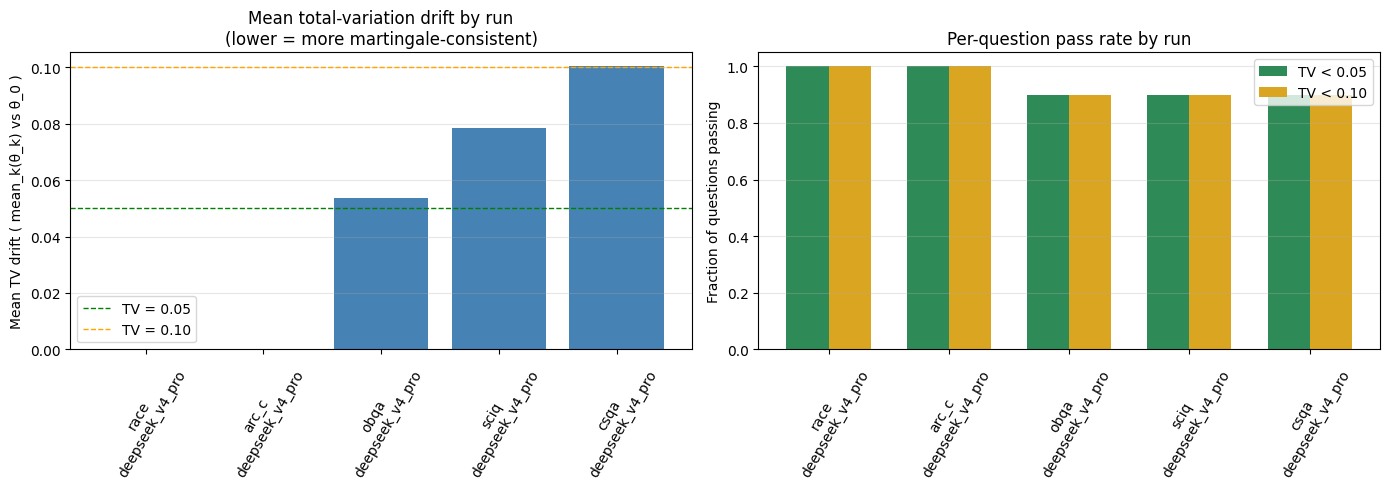

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = overview["dataset"] + "\n" + overview["model"]

ax = axes[0]
ax.bar(labels, overview["mean_tv"], color="steelblue")
ax.axhline(0.05, color="green", linestyle="--", linewidth=1, label="TV = 0.05")
ax.axhline(0.10, color="orange", linestyle="--", linewidth=1, label="TV = 0.10")
ax.set_ylabel("Mean TV drift ( mean_k(θ_k) vs θ_0 )")
ax.set_title("Mean total-variation drift by run\n(lower = more martingale-consistent)")
ax.tick_params(axis="x", rotation=60)
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

ax = axes[1]
width = 0.35
x = np.arange(len(overview))
ax.bar(x - width/2, overview["pass_rate_tv_0.05"], width, label="TV < 0.05", color="seagreen")
ax.bar(x + width/2, overview["pass_rate_tv_0.10"], width, label="TV < 0.10", color="goldenrod")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=60)
ax.set_ylabel("Fraction of questions passing")
ax.set_title("Per-question pass rate by run")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


## 3b. Argmax agreement (label-level drift)

`mean_tv`/`mean_l1` and the parametric tests in Section 4 are underpowered
here for two compounding reasons: (a) each run has only **N=10 questions**,
so paired/KS tests have little chance of reaching significance even for a
real shift; (b) several runs (the `deepseek_v4_pro` ones) return
near one-hot distributions (no `logprobs`, effectively a single greedy
sample per call), which collapses most soft-probability tests onto a
handful of point masses.

For this regime the most direct, assumption-free question is simply: **does
self-conditioning ever change which answer the model would pick?** For each
question we compare $\arg\max_c \theta_k[c]$ at every step $k\ge1$ against
$\arg\max_c \theta_0[c]$ and report the disagreement rate. This needs no
p-value to be informative — it's the raw behavioral fact the martingale
property is meant to rule out.


In [8]:
argmax_rows = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    p_all = dat["distributions"].mean(axis=1)   # (Q, K+1, C)
    argmax_all = p_all.argmax(axis=-1)          # (Q, K+1)
    label0 = argmax_all[:, :1]                  # (Q, 1)
    disagree = (argmax_all[:, 1:] != label0)    # (Q, K)  True where step k picks a different class than step 0

    argmax_rows.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "flip_rate": float(disagree.mean()),                       # fraction of (question, step) pairs that disagree
        "questions_with_any_flip": int((disagree.any(axis=1)).sum()),
        "n_questions": disagree.shape[0],
    })

argmax_summary = pd.DataFrame(argmax_rows).sort_values("flip_rate", ascending=False).reset_index(drop=True)
argmax_summary["pct_questions_with_flip"] = argmax_summary["questions_with_any_flip"] / argmax_summary["n_questions"]
argmax_summary.style.format({"flip_rate": "{:.4f}", "pct_questions_with_flip": "{:.1%}"})


,dataset,model,flip_rate,questions_with_any_flip,n_questions,pct_questions_with_flip
0,csqa,deepseek_v4_pro,0.1003,2,10,20.0%
1,sciq,deepseek_v4_pro,0.0783,1,10,10.0%
2,obqa,deepseek_v4_pro,0.0537,1,10,10.0%
3,arc_c,deepseek_v4_pro,0.0000,0,10,0.0%
4,race,deepseek_v4_pro,0.0000,0,10,0.0%


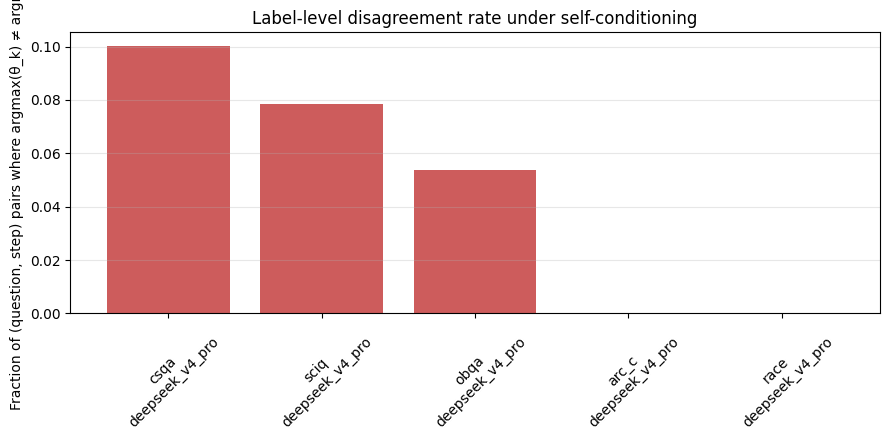

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = argmax_summary["dataset"] + "\n" + argmax_summary["model"]
ax.bar(labels, argmax_summary["flip_rate"], color="indianred")
ax.set_ylabel("Fraction of (question, step) pairs where argmax(θ_k) ≠ argmax(θ_0)")
ax.set_title("Label-level disagreement rate under self-conditioning")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## 4. Statistical test suite

The overview above only tells us *how much* belief moved on average. The
functions below test *whether that movement is statistically meaningful*
(and in which direction), following the four properties in the intro.

All functions operate on `p_all`, the trajectories averaged over
trajectories $J$ (identity when $J=1$, i.e. for every run currently in
`results_mp`): shape `(Q, K+1, C)`.


In [19]:
EPS = 1e-9

def to_clr(p: np.ndarray) -> np.ndarray:
    """Centered log-ratio transform: maps the simplex to unconstrained R^C."""
    p = np.clip(p, EPS, 1)
    log_p = np.log(p)
    return log_p - log_p.mean(axis=-1, keepdims=True)


def smooth_cdf(values: np.ndarray, x_grid: np.ndarray, bw: float = 0.5) -> np.ndarray:
    """KDE-smoothed CDF; falls back to the ECDF if the sample is (near-)degenerate."""
    values = np.asarray(values)
    if values.std() < 0.1 or len(values) < 3:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)
    try:
        kde = gaussian_kde(values, bw_method=bw)
        density = kde(x_grid)
        cdf = cumulative_trapezoid(density, x_grid, initial=0)
        cdf /= cdf[-1]
        return cdf
    except np.linalg.LinAlgError:
        return np.mean(values[:, None] <= x_grid[None, :], axis=0).astype(float)


### Test 1 — Mean stability (TV/L1 drift + paired tests + CLR-space CDF comparison)

Compares $\theta_0$ (Scenario 1: direct prediction) against
$\{\theta_k\}_{k=1}^K$ (Scenario 2: self-conditioned). Under the martingale
property these should be statistically indistinguishable:
$\mathbb{E}_k[\theta_k] = \theta_0$.


In [20]:
def scenario_comparison_test(p_0: np.ndarray, p_others: np.ndarray, alpha: float = 0.05,
                              class_labels=None, make_plots: bool = True, title: str = ""):
    """
    p_0      : (Q, C)    direct-query prior, one per question
    p_others : (Q, K, C) self-conditioned posteriors, K steps per question

    Returns a dict of scalar statistics plus a boolean 'martingale_consistent' verdict.
    """
    Q, K, C = p_others.shape
    class_labels = class_labels or [chr(65 + c) for c in range(C)]
    steps = np.arange(1, K + 1)

    p_others_mean = p_others.mean(axis=1)  # (Q, C) — per-question average posterior

    tv_per_q = 0.5 * np.abs(p_0 - p_others_mean).sum(axis=1)                 # (Q,)
    tv_per_step = 0.5 * np.abs(p_0[:, None, :] - p_others).sum(axis=-1).mean(axis=0)  # (K,)

    m_dist = 0.5 * (p_0 + p_others_mean)
    jsd = 0.5 * (
        rel_entr(p_0, np.clip(m_dist, EPS, 1)).sum(axis=1)
        + rel_entr(p_others_mean, np.clip(m_dist, EPS, 1)).sum(axis=1)
    )  # (Q,)

    # Paired t-test also runs in CLR space, for the same reason as the KS
    # test below: on the raw simplex, two supposedly-identical probabilities
    # (e.g. both ~0.1) can differ by ~1e-11 due to float32->float64 noise,
    # and ttest_rel divides by the standard error *of that noise*, which can
    # spuriously cross p<0.05. CLR's EPS-clipping removes it.
    p_0_clr_t = to_clr(p_0)
    p_others_mean_clr = to_clr(p_others_mean)
    ttest_pvals = np.array([
        stats.ttest_rel(p_0_clr_t[:, c], p_others_mean_clr[:, c]).pvalue for c in range(C)
    ])

    # KS test is run in CLR space (not on raw probabilities): near one-hot
    # providers (e.g. a chat API with no logprobs) emit "near-zero" entries
    # that differ only by float32 noise far below any meaningful precision
    # (e.g. 1.00000001e-10 vs 9.99999944e-11). Pooling millions of such raw
    # values makes ks_2samp detect that noise as a "significant" shift even
    # when every distribution is bit-for-bit the same one-hot vector. CLR's
    # EPS-clipping collapses all such near-zero entries to one value, so the
    # test again reflects genuine distributional shape differences only.
    p_0_clr = to_clr(p_0)
    p_others_clr = to_clr(p_others)
    ks_stat, ks_pval = ks_2samp(p_others_clr.reshape(-1, C).ravel(), np.tile(p_0_clr, (K, 1)).ravel())

    n_sig_classes = int((ttest_pvals < alpha).sum())
    martingale_consistent = bool(ks_pval >= alpha and n_sig_classes == 0)

    if make_plots:
        fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
        fig.suptitle(f"Scenario comparison (θ_0 vs self-conditioned θ_k) — {title}", y=1.04)

        ax = axes[0]
        ax.bar(range(Q), tv_per_q, color="steelblue")
        ax.axhline(tv_per_q.mean(), color="red", linestyle="--", label=f"mean={tv_per_q.mean():.3f}")
        ax.set_xlabel("Question"); ax.set_ylabel("TV distance")
        ax.set_title("TV(θ_0, mean_k θ_k) per question"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.plot(steps, tv_per_step, marker="o", color="steelblue")
        ax.axhline(tv_per_step.mean(), color="red", linestyle="--", label=f"mean={tv_per_step.mean():.3f}")
        ax.set_xlabel("Step k"); ax.set_ylabel("Mean TV distance vs θ_0")
        ax.set_title("TV drift over self-conditioning steps"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[2]
        ax.bar(range(Q), jsd, color="orange")
        ax.axhline(jsd.mean(), color="red", linestyle="--", label=f"mean={jsd.mean():.3f}")
        ax.set_xlabel("Question"); ax.set_ylabel("JSD")
        ax.set_title("Jensen-Shannon divergence per question"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

        ax = axes[3]
        x = np.arange(C); w = 0.35
        ax.bar(x - w/2, p_0.mean(axis=0), width=w, label="θ_0 (prior)", color="steelblue")
        ax.bar(x + w/2, p_others_mean.mean(axis=0), width=w, label="mean θ_k (posterior)", color="orange")
        for c in range(C):
            if ttest_pvals[c] < alpha:
                ymax = max(p_0[:, c].mean(), p_others_mean[:, c].mean()) + 0.01
                ax.text(c, ymax, "*", ha="center", fontsize=14, color="red")
        ax.set_xticks(x); ax.set_xticklabels(class_labels)
        ax.set_ylabel("Mean probability"); ax.set_title("Mean belief per class (* = p<α)")
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    return {
        "tv_mean": float(tv_per_q.mean()),
        "jsd_mean": float(jsd.mean()),
        "ks_stat": float(ks_stat), "ks_pval": float(ks_pval),
        "n_sig_classes": n_sig_classes, "n_classes": C,
        "martingale_consistent": martingale_consistent,
    }


### Test 2 — Marginal-distribution KS test per step + epistemic entropy trend

For each step $k$, we CLR-transform $\theta_k$ pooled over all questions and
run a two-sample Kolmogorov–Smirnov test against the pooled $\theta_0$
values. If the martingale property holds, no step should show a
significant shift. We also report the trend of mean predictive entropy
across steps for context (a genuinely Bayesian process is *not* required to
have monotonically shrinking entropy here, since no new evidence is being
introduced — a flat trend is consistent with the martingale property; a
strong monotonic *decrease* signals overconfidence/entrenchment, and an
*increase* signals eroding certainty).


In [11]:
def marginal_ks_and_entropy_test(p_all: np.ndarray, alpha: float = 0.05,
                                  make_plots: bool = True, title: str = ""):
    """p_all: (Q, T, C) trajectories (T = K+1 steps, step 0 = prior)."""
    Q, T, C = p_all.shape
    steps = np.arange(T)
    p_clr = to_clr(p_all)

    ref = p_clr[:, 0, :].ravel()
    ks_pvals = np.ones(T)
    ks_stats = np.zeros(T)
    for m in range(1, T):
        ks_stats[m], ks_pvals[m] = ks_2samp(ref, p_clr[:, m, :].ravel())

    p_clip = np.clip(p_all, EPS, 1)
    entropy = -(p_all * np.log(p_clip)).sum(axis=-1)  # (Q, T)
    mean_entropy = entropy.mean(axis=0)
    rho, rho_pval = stats.spearmanr(steps[1:], mean_entropy[1:])

    n_sig = int((ks_pvals[1:] < alpha).sum())
    martingale_consistent = bool(n_sig == 0)

    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
        fig.suptitle(f"Marginal KS test & entropy trend — {title}", y=1.03)

        ax = axes[0]
        ax.plot(steps[1:], ks_pvals[1:], marker="o", color="steelblue", markersize=3)
        ax.axhline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        ax.set_xlabel("Step k"); ax.set_ylabel("KS p-value (θ_k vs θ_0)")
        ax.set_title(f"{n_sig}/{T-1} steps significantly shifted")
        ax.legend(); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.plot(steps, mean_entropy, marker="o", color="orange", markersize=3)
        ax.set_xlabel("Step k"); ax.set_ylabel("Mean entropy H(θ_k)")
        ax.set_title(f"Entropy trend — Spearman ρ={rho:.3f}, p={rho_pval:.4f}")
        ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    return {
        "n_sig_steps": n_sig, "n_steps": T - 1,
        "entropy_rho": float(rho), "entropy_rho_pval": float(rho_pval),
        "martingale_consistent": martingale_consistent,
    }


### Test 3 — Martingale Score: does $\Delta\theta_k$ depend on $\theta_k$?

For every question we have one path $\theta_0, \theta_1, \dots, \theta_K$
(here each question *is* an independent path — there is no additional
trajectory dimension in the iterative-mode data). Pooling
$(\theta_k, \Delta\theta_k)$ pairs across all questions and steps, we
regress the increment on the *scalar* top-class belief
$b_k = \max_c \theta_k[c]$:

$$\Delta b_k = \beta_0 + \beta_1 \, b_k + \varepsilon_k$$

- $\hat\beta_1 \approx 0$ (not significant) → martingale holds
- $\hat\beta_1 > 0$ → **belief entrenchment** (confident beliefs get more confident)
- $\hat\beta_1 < 0$ → mean-reversion


In [12]:
def martingale_score(distributions: np.ndarray, alpha: float = 0.05,
                      make_plots: bool = True, title: str = ""):
    """distributions: (Q, J, K+1, C). Pools all Q*J independent paths.

    Some providers (e.g. a chat API with no logprobs access, single-sample
    greedy decoding) return near one-hot distributions, so the top-class
    belief b_k = max_c θ_k[c] is ~1 at every step for every path. The
    regression predictor is then degenerate (zero variance) and OLS is
    undefined; this is reported explicitly rather than crashing or silently
    returning a bogus '0 == pass'.
    """
    Q, J, Kp1, C = distributions.shape
    b = distributions.max(axis=-1).reshape(Q * J, Kp1)  # (paths, K+1)

    X = b[:, :-1].reshape(-1)
    diff = (b[:, 1:] - b[:, :-1]).reshape(-1)
    n = len(X)

    if X.std() < 1e-8:
        if make_plots:
            print(f"[martingale_score] SKIPPED for {title}: max-belief is constant "
                  f"(std={X.std():.2e}) — model returns near one-hot distributions, "
                  "so this regression test is not applicable.")
        return {
            "beta_1": float("nan"), "std_err": float("nan"), "p_value": float("nan"),
            "r2": float("nan"), "f_stat": float("nan"), "f_pvalue": float("nan"),
            "martingale_consistent": None,  # not applicable, neither pass nor fail
            "degenerate": True,
        }

    slope, intercept, r_value, p_value, std_err = stats.linregress(X, diff)
    r2 = r_value ** 2
    t_stat = slope / std_err if std_err > 0 else 0.0
    f_stat = t_stat ** 2
    f_pvalue = stats.f.sf(f_stat, dfn=1, dfd=n - 2)

    martingale_consistent = bool(p_value >= alpha)

    if make_plots:
        fig, ax = plt.subplots(figsize=(6, 4.5))
        ax.scatter(X, diff, alpha=0.15, s=10, color="steelblue")
        xs = np.linspace(X.min(), X.max(), 50)
        ax.plot(xs, intercept + slope * xs, color="red", linewidth=2,
                label=f"β̂₁={slope:.3f} (p={p_value:.4f})")
        ax.axhline(0, color="gray", linewidth=0.8)
        ax.set_xlabel("b_k = max belief at step k")
        ax.set_ylabel("Δb = b_{k+1} - b_k")
        ax.set_title(f"Martingale Score — {title}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

    return {
        "beta_1": float(slope), "std_err": float(std_err), "p_value": float(p_value),
        "r2": float(r2), "f_stat": float(f_stat), "f_pvalue": float(f_pvalue),
        "martingale_consistent": martingale_consistent,
        "degenerate": False,
    }


### Test 4 — Ljung–Box independence test on increments

A martingale difference sequence should be serially uncorrelated. For each
question's class-wise increment series $\Delta\theta_k[c]$ we run a
Ljung–Box test (implemented directly with `scipy.stats.chi2` — no extra
dependency) up to `lags` lags and report the fraction of (question, class)
series where independence is *not* rejected.


In [13]:
def ljung_box(x: np.ndarray, lags: int = 5):
    """Ljung-Box Q-statistic and p-value for serial correlation up to `lags`."""
    x = np.asarray(x, dtype=np.float64)
    n = len(x)
    x_c = x - x.mean()
    denom = np.sum(x_c ** 2)
    if denom < 1e-12 or n <= lags + 2:
        return 0.0, 1.0
    acf = np.array([
        np.sum(x_c[k:] * x_c[:-k]) / denom for k in range(1, lags + 1)
    ])
    q_stat = n * (n + 2) * np.sum(acf ** 2 / (n - np.arange(1, lags + 1)))
    p_value = chi2.sf(q_stat, df=lags)
    return float(q_stat), float(p_value)


def independence_test(p_all: np.ndarray, lags: int = 5, alpha: float = 0.05,
                       make_plots: bool = True, title: str = ""):
    """p_all: (Q, T, C). Runs Ljung-Box per (question, class) on Δθ."""
    Q, T, C = p_all.shape
    delta = np.diff(p_all, axis=1)  # (Q, T-1, C)

    pvals = np.zeros((Q, C))
    for q in range(Q):
        for c in range(C):
            _, pvals[q, c] = ljung_box(delta[q, :, c], lags=lags)

    pass_rate = float((pvals >= alpha).mean())
    martingale_consistent = bool(pass_rate >= 0.95)

    if make_plots:
        mean_delta = delta.mean(axis=(0, 2))  # averaged series for a representative ACF plot
        n = len(mean_delta)
        x_c = mean_delta - mean_delta.mean()
        denom = np.sum(x_c ** 2) + EPS
        max_lag = min(lags * 2, n // 2)
        acf_vals = [np.sum(x_c[k:] * x_c[:-k]) / denom for k in range(1, max_lag + 1)]
        ci = 1.96 / np.sqrt(n)

        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle(f"Independence of increments (Ljung-Box, lags={lags}) — {title}", y=1.03)

        ax = axes[0]
        ax.bar(range(1, max_lag + 1), acf_vals, color="steelblue")
        ax.axhline(ci, color="red", linestyle="--", linewidth=1)
        ax.axhline(-ci, color="red", linestyle="--", linewidth=1)
        ax.set_xlabel("Lag"); ax.set_ylabel("ACF of mean Δθ")
        ax.set_title("Autocorrelation of question/class-averaged Δθ"); ax.grid(alpha=0.3)

        ax = axes[1]
        ax.hist(pvals.ravel(), bins=20, color="steelblue", edgecolor="white")
        ax.axvline(alpha, color="red", linestyle="--", label=f"α={alpha}")
        ax.set_xlabel("Ljung-Box p-value"); ax.set_ylabel("Count (question × class)")
        ax.set_title(f"Pass rate (p≥α): {pass_rate:.1%}")
        ax.legend(); ax.grid(alpha=0.3)

        plt.tight_layout(); plt.show()

    return {
        "pass_rate": pass_rate, "n_series": Q * C,
        "martingale_consistent": martingale_consistent,
    }


### CLR-space CDF visualisation

A qualitative companion to Test 1: plot the empirical CDF (in CLR space) of
$\theta_0$ against the empirical CDF of $\{\theta_k\}_{k=1}^{K}$ pooled
across questions and steps. Overlapping curves support the martingale
property; a systematic horizontal offset indicates drift.


In [14]:
def plot_clr_cdf_comparison(p_all: np.ndarray, k_max: int = None, title: str = ""):
    """p_all: (Q, T, C). Compares CLR(θ_0) vs CLR({θ_k}_{k=1..k_max}) as CDFs."""
    Q, T, C = p_all.shape
    k_max = k_max or (T - 1)
    p_clr_all = to_clr(p_all)
    p0_clr = p_clr_all[:, 0, :]
    steps_clr = p_clr_all[:, 1:k_max + 1, :].reshape(-1, C)

    clip = max(np.abs(steps_clr).max(), np.abs(p0_clr).max())
    x_grid = np.linspace(-clip, clip, 400)

    fig, ax = plt.subplots(figsize=(7, 5))
    for dist in np.clip(steps_clr, -clip, clip)[:: max(1, len(steps_clr) // 300)]:
        ax.plot(x_grid, smooth_cdf(dist, x_grid), color="steelblue", alpha=0.05, linewidth=0.8)

    mean_post_cdf = np.mean([smooth_cdf(d, x_grid) for d in np.clip(steps_clr, -clip, clip)], axis=0)
    mean_prior_cdf = np.mean([smooth_cdf(d, x_grid) for d in np.clip(p0_clr, -clip, clip)], axis=0)

    ax.plot(x_grid, mean_post_cdf, color="orange", linewidth=2.5, label=f"Mean CDF, k=1..{k_max}")
    ax.plot(x_grid, mean_prior_cdf, color="red", linestyle="--", linewidth=2.5, label="Initial CDF (θ_0)")
    ax.set_xlabel("CLR value"); ax.set_ylabel("CDF")
    ax.set_title(f"CLR-space belief distribution — {title}")
    ax.set_xlim(-clip, clip); ax.legend(loc="upper left"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()


### Battery runner

Bundles all four tests plus the drift-profile / CDF plots into one call, and
produces a single overall verdict (martingale property holds only if *all
four* tests are consistent).


In [15]:
def run_full_battery(dat: dict, name: str = "", alpha: float = 0.05, make_plots: bool = True) -> dict:
    distributions = dat["distributions"]          # (Q, J, K+1, C)
    p_all = distributions.mean(axis=1)             # (Q, K+1, C) — mean over trajectories
    p_0 = p_all[:, 0, :]
    p_others = p_all[:, 1:, :]

    if make_plots:
        Q, Kp1, C = p_all.shape
        fig, ax = plt.subplots(figsize=(9, 4))
        drift = np.abs(p_all[:, 1:, :] - p_0[:, None, :]).sum(axis=-1)  # (Q, K)
        mean_drift = drift.mean(axis=0)
        std_drift = drift.std(axis=0)
        x = np.arange(1, Kp1)
        ax.plot(x, mean_drift, color="steelblue", label="mean L1 drift")
        ax.fill_between(x, mean_drift - std_drift, mean_drift + std_drift, color="steelblue", alpha=0.2, label="±1 std")
        ax.set_xlabel("Step k"); ax.set_ylabel(r"$\Vert\theta_k-\theta_0\Vert_1$")
        ax.set_title(f"Drift-from-origin profile — {name}")
        ax.legend(); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

        plot_clr_cdf_comparison(p_all, title=name)

    res_scenario = scenario_comparison_test(p_0, p_others, alpha=alpha, make_plots=make_plots, title=name)
    res_marginal = marginal_ks_and_entropy_test(p_all, alpha=alpha, make_plots=make_plots, title=name)
    res_score = martingale_score(distributions, alpha=alpha, make_plots=make_plots, title=name)
    res_indep = independence_test(p_all, alpha=alpha, make_plots=make_plots, title=name)

    def _verdict_str(v):
        return "N/A" if v is None else ("PASS" if v else "FAIL")

    # Test 3 verdict is None (not applicable) when the model returns near
    # one-hot distributions; overall verdict then depends only on tests 1/2/4.
    applicable = [
        res_scenario["martingale_consistent"], res_marginal["martingale_consistent"],
        res_score["martingale_consistent"], res_indep["martingale_consistent"],
    ]
    overall = all(v for v in applicable if v is not None)

    if make_plots:
        print(f"=== Verdict for {name} ===")
        print(f"  Test 1 (scenario comparison)      : {_verdict_str(res_scenario['martingale_consistent'])}  "
              f"(TV={res_scenario['tv_mean']:.4f}, KS p={res_scenario['ks_pval']:.4f}, "
              f"{res_scenario['n_sig_classes']}/{res_scenario['n_classes']} classes shifted)")
        print(f"  Test 2 (marginal KS per step)     : {_verdict_str(res_marginal['martingale_consistent'])}  "
              f"({res_marginal['n_sig_steps']}/{res_marginal['n_steps']} steps shifted, "
              f"entropy ρ={res_marginal['entropy_rho']:.3f} p={res_marginal['entropy_rho_pval']:.4f})")
        print(f"  Test 3 (martingale score β̂₁)      : {_verdict_str(res_score['martingale_consistent'])}  "
              f"(β̂₁={res_score['beta_1']:.4f}, p={res_score['p_value']:.4f}, R²={res_score['r2']:.4f})")
        print(f"  Test 4 (Ljung-Box independence)   : {_verdict_str(res_indep['martingale_consistent'])}  "
              f"(pass rate={res_indep['pass_rate']:.1%} of {res_indep['n_series']} series)")
        print(f"  --> OVERALL: {'MARTINGALE CONSISTENT' if overall else 'MARTINGALE VIOLATED'}")

    return {
        "name": name,
        "scenario": res_scenario, "marginal": res_marginal,
        "score": res_score, "independence": res_indep,
        "overall_consistent": overall,
    }


## 5. Deep dive on one run

Pick any completed run below and see the full battery with all diagnostic
plots. Change `DATASET_KEY` to any `folder` value from the registry in
Section 1.


Available run keys: ['arc_c_deepseek_v4_pro', 'csqa_deepseek_v4_pro', 'obqa_deepseek_v4_pro', 'race_deepseek_v4_pro', 'sciq_deepseek_v4_pro']

Deep-diving into: arc_c_deepseek_v4_pro  (dataset=arc_c, model=deepseek_v4_pro)


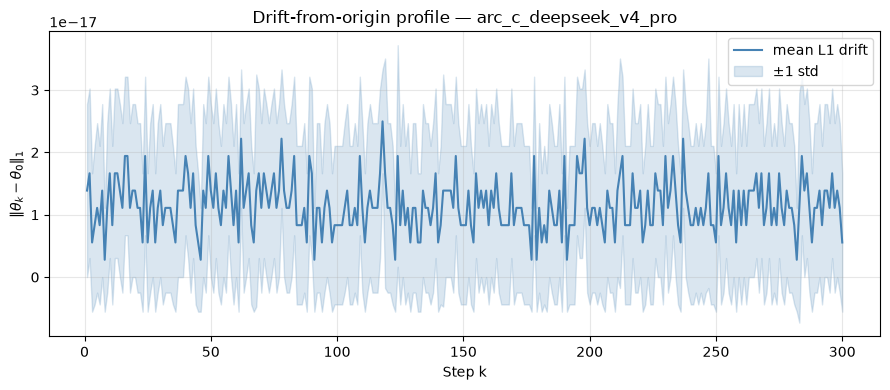

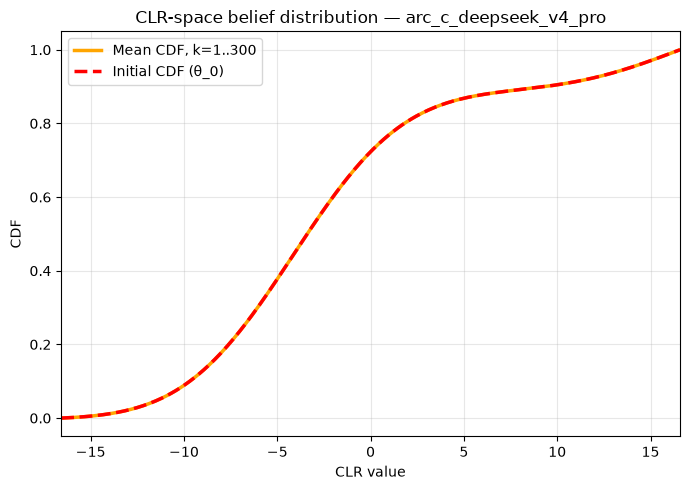

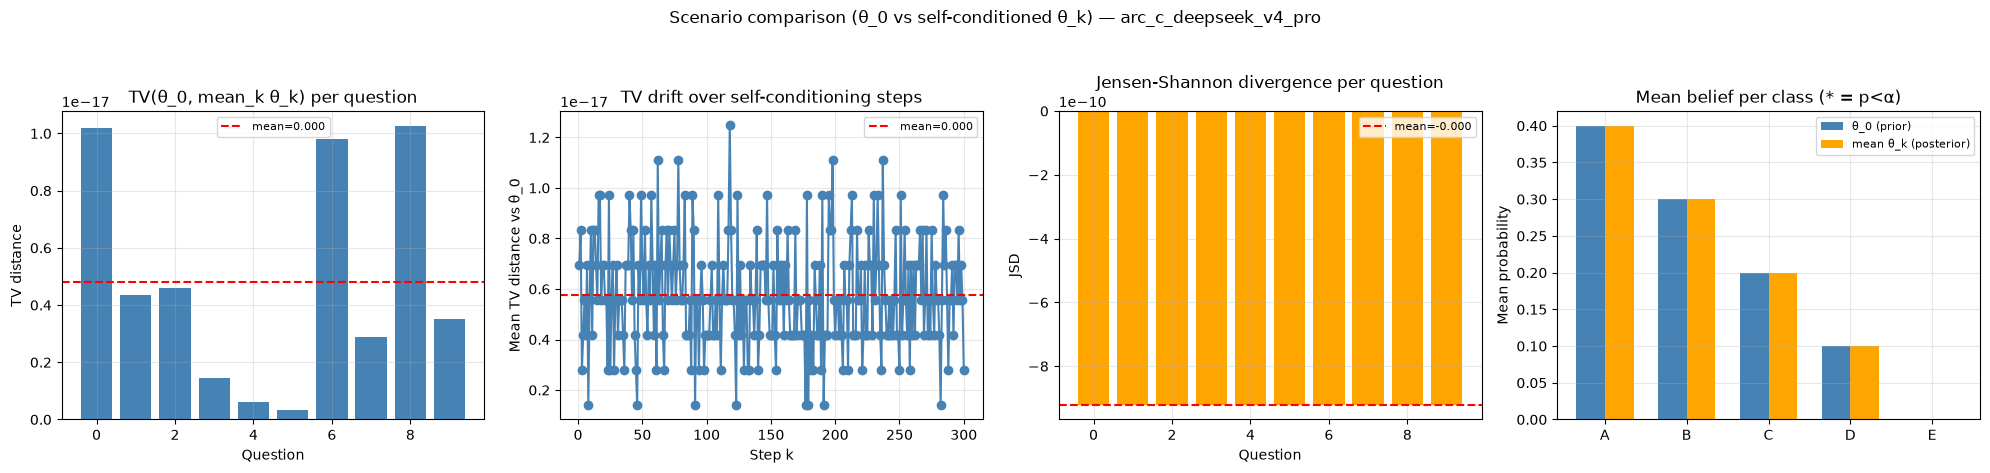

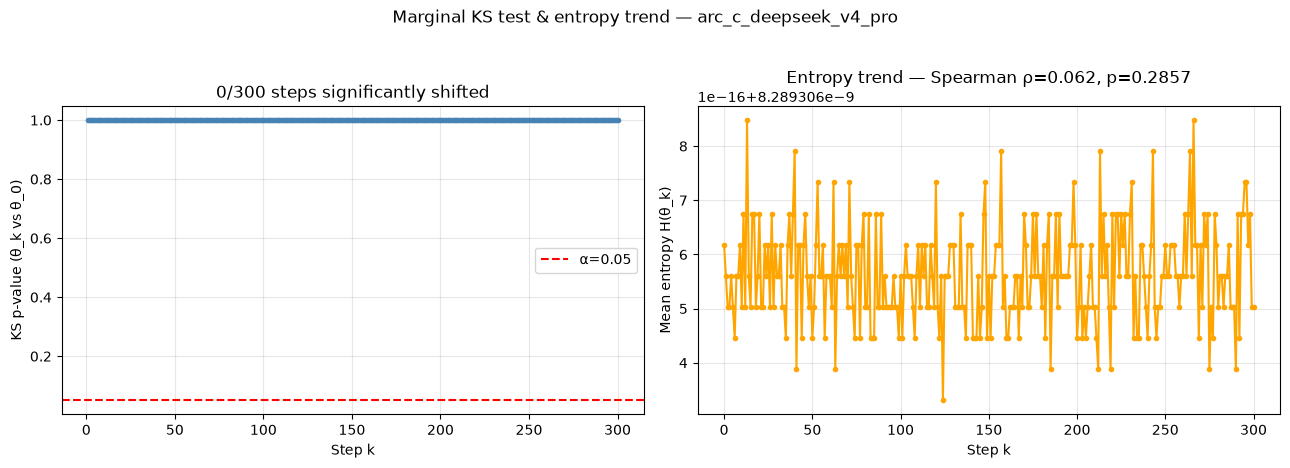

[martingale_score] SKIPPED for arc_c_deepseek_v4_pro: max-belief is constant (std=0.00e+00) — model returns near one-hot distributions, so this regression test is not applicable.


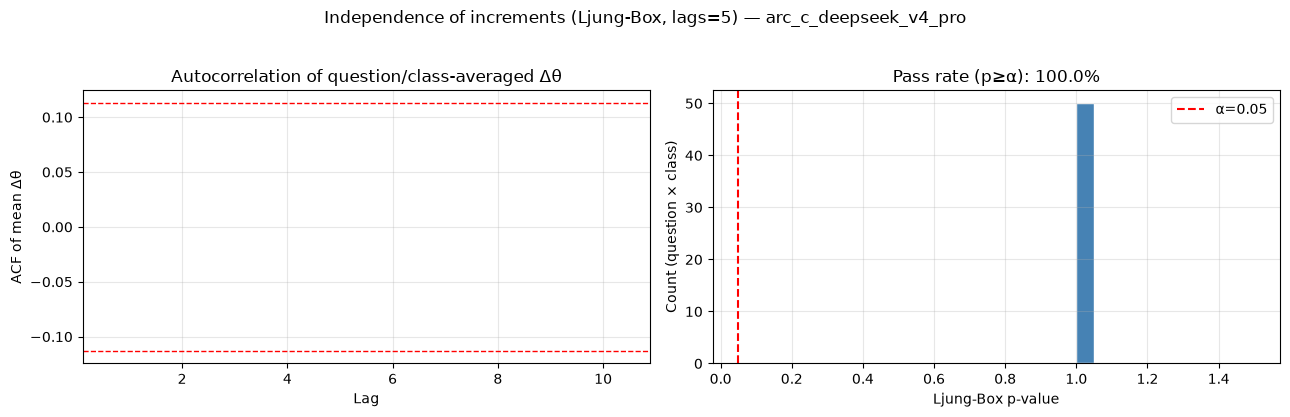

=== Verdict for arc_c_deepseek_v4_pro ===
  Test 1 (scenario comparison)      : PASS  (TV=0.0000, KS p=1.0000, 0/5 classes shifted)
  Test 2 (marginal KS per step)     : PASS  (0/300 steps shifted, entropy ρ=0.062 p=0.2857)
  Test 3 (martingale score β̂₁)      : N/A  (β̂₁=nan, p=nan, R²=nan)
  Test 4 (Ljung-Box independence)   : PASS  (pass rate=100.0% of 50 series)
  --> OVERALL: MARTINGALE CONSISTENT


In [16]:
print("Available run keys:", registry["folder"].tolist())

DATASET_KEY = registry.loc[0, "folder"]  # <-- change this to inspect a different run
run_row = registry.loc[registry["folder"] == DATASET_KEY].iloc[0]
dat = load_run(run_row["npz_path"])

print(f"\nDeep-diving into: {DATASET_KEY}  (dataset={run_row['dataset']}, model={run_row['model']})")
deep_dive_result = run_full_battery(dat, name=DATASET_KEY, alpha=0.05, make_plots=True)


## 6. Batch verdicts across every available run

Runs the same battery (statistics only, no plots) over every completed run
and collects the four test verdicts plus an overall call into one table.


In [17]:
ALPHA = 0.05
batch_results = []
for _, row in registry.iterrows():
    dat = load_run(row["npz_path"])
    res = run_full_battery(dat, name=row["folder"], alpha=ALPHA, make_plots=False)
    batch_results.append({
        "dataset": row["dataset"],
        "model": row["model"],
        "scenario_tv": res["scenario"]["tv_mean"],
        "scenario_pass": res["scenario"]["martingale_consistent"],
        "marginal_sig_steps": f"{res['marginal']['n_sig_steps']}/{res['marginal']['n_steps']}",
        "marginal_pass": res["marginal"]["martingale_consistent"],
        "score_beta1": res["score"]["beta_1"],
        "score_pval": res["score"]["p_value"],
        "score_pass": res["score"]["martingale_consistent"] if not res["score"]["degenerate"] else "N/A (one-hot)",
        "indep_pass_rate": res["independence"]["pass_rate"],
        "indep_pass": res["independence"]["martingale_consistent"],
        "OVERALL": "CONSISTENT" if res["overall_consistent"] else "VIOLATED",
    })

summary = pd.DataFrame(batch_results)
summary


,dataset,model,scenario_tv,scenario_pass,marginal_sig_steps,marginal_pass,score_beta1,score_pval,score_pass,indep_pass_rate,indep_pass,OVERALL
0,arc_c,deepseek_v4_pro,4.792463e-18,True,0/300,True,NaN,NaN,N/A (one-hot),1.00,True,CONSISTENT
1,csqa,deepseek_v4_pro,1.003333e-01,True,0/300,True,NaN,NaN,N/A (one-hot),0.96,True,CONSISTENT
2,obqa,deepseek_v4_pro,5.366667e-02,True,0/300,True,NaN,NaN,N/A (one-hot),1.00,True,CONSISTENT
3,race,deepseek_v4_pro,4.989065e-18,True,0/300,True,NaN,NaN,N/A (one-hot),1.00,True,CONSISTENT
4,sciq,deepseek_v4_pro,7.833333e-02,True,0/300,True,NaN,NaN,N/A (one-hot),1.00,True,CONSISTENT


In [18]:
def _highlight_overall(row):
    color = "background-color: #c8e6c9" if row["OVERALL"] == "CONSISTENT" else "background-color: #ffcdd2"
    return [color if col == "OVERALL" else "" for col in row.index]

summary.style.apply(_highlight_overall, axis=1).format({
    "scenario_tv": "{:.4f}", "score_beta1": "{:.4f}", "score_pval": "{:.4f}",
    "indep_pass_rate": "{:.1%}",
})


,dataset,model,scenario_tv,scenario_pass,marginal_sig_steps,marginal_pass,score_beta1,score_pval,score_pass,indep_pass_rate,indep_pass,OVERALL
0,arc_c,deepseek_v4_pro,0.0000,True,0/300,True,nan,nan,N/A (one-hot),100.0%,True,CONSISTENT
1,csqa,deepseek_v4_pro,0.1003,True,0/300,True,nan,nan,N/A (one-hot),96.0%,True,CONSISTENT
2,obqa,deepseek_v4_pro,0.0537,True,0/300,True,nan,nan,N/A (one-hot),100.0%,True,CONSISTENT
3,race,deepseek_v4_pro,0.0000,True,0/300,True,nan,nan,N/A (one-hot),100.0%,True,CONSISTENT
4,sciq,deepseek_v4_pro,0.0783,True,0/300,True,nan,nan,N/A (one-hot),100.0%,True,CONSISTENT


## 7. Interpretation

- **Test 1 (scenario comparison)** is the most direct read of the paper's
  Figure-2-style check: does feeding the model its own sampled answers shift
  its belief away from the zero-shot prior? A significant KS test or paired
  t-test on any class means the answer is yes.
- **Test 2 (marginal KS per step)** localizes *when* drift appears — a model
  might be stable for the first few self-conditioning steps and only drift
  once enough of its own samples accumulate in context.
- **Test 3 (martingale score)** is the sharpest quantitative signal:
  $\hat\beta_1 > 0$ with a small p-value is direct evidence of belief
  entrenchment (the model digs in on whatever it said first), while
  $\hat\beta_1 < 0$ indicates mean-reversion.
- **Test 4 (independence)** flags cases where consecutive updates are
  correlated — e.g. a model that overshoots then corrects, which would still
  average out in Test 1 but is not memoryless.

A dataset/model combination should only be treated as genuinely
martingale-consistent if **all four** tests pass; passing only the mean-drift
test (1) while failing the regression test (3) is a common pattern for
models that drift slowly but systematically in one direction.

**Caveats specific to this data.** Every run currently in `results_mp` has
only `N=10` questions, so the parametric tests above (paired t-test, KS,
OLS) have limited statistical power — a real but modest shift can easily
fail to reach `p<0.05`. The `deepseek_v4_pro` runs additionally return
near one-hot distributions (no `logprobs` access), which makes Test 3
inapplicable (the regression predictor is degenerate) and reduces Tests 1–2
to comparing point masses. In this regime, **Section 3b's argmax agreement
rate is the most trustworthy signal**: it directly answers "how often does
showing the model its own earlier answers change what it would pick?"
without relying on asymptotic test assumptions that don't hold at `N=10`.
Runs with a non-trivial `flip_rate` in Section 3b (e.g. `csqa`, `obqa`,
`sciq` at the time of writing) show real, if modest, label-level drift that
the formal battery is too underpowered to certify — treat the four-test
`OVERALL` verdict as a lower bound on evidence of drift, not proof of its
absence.
